# 📊 Model Comparison
## `02 — Baseline vs Prophet vs LightGBM`

Reuses functions from `pipeline/train.py` and `pipeline/evaluate.py`.

| Section | What it covers |
|---|---|
| 1 — Load & prepare | Clean data + build features |
| 2 — Baseline | Naive average — the bar every model must beat |
| 3 — LightGBM | Gradient boosting across all SKUs |
| 4 — Prophet | Statistical model per SKU |
| 5 — Comparison | Metrics table + visual comparison |
| 6 — Walk-forward | Rolling validation per model |
| 7 — Verdict | Which model goes to production |

---
## 0. Setup

In [ ]:
import os
os.chdir("..")
import warnings
warnings.filterwarnings('ignore')

from dotenv import load_dotenv
load_dotenv('../.env')  # go up one level from notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error

from src.config   import FEATURE_COLS, TARGET_COL, SKU_COL, DATE_COL, MODEL_PATH
from src.clean    import load_raw_data, clean_sales, clean_inventory, clean_catalog
from src.features import build_features
from src.train    import split_train_test, train_baseline, evaluate_baseline, train_model
from src.evaluate import compute_metrics, plot_feature_importance, walk_forward_eval

print('✅ Ready')

Importing plotly failed. Interactive plots will not work.


✅ Ready


---
## 1. Load & Prepare Data

In [2]:
sales, inventory, catalog = load_raw_data()

sales     = clean_sales(sales, inventory)
inventory = clean_inventory(inventory)
catalog   = clean_catalog(catalog)

features_df = build_features(sales, inventory, catalog)
train, test = split_train_test(features_df)

X_train = train[FEATURE_COLS].fillna(0)
y_train = train[TARGET_COL]
X_test  = test[FEATURE_COLS].fillna(0)
y_test  = test[TARGET_COL]

print(f'Train : {len(train):,} rows')
print(f'Test  : {len(test):,}  rows')

2026-05-01 08:06:39,048 — Loading raw files...
2026-05-01 08:06:39,227 — Empty rows dropped : 66,864
2026-05-01 08:06:39,229 — Negative units dropped : 667
2026-05-01 08:06:39,245 — Duplicates dropped : 0
2026-05-01 08:06:39,246 — Sales rows after cleaning : 32,469
2026-05-01 08:06:39,266 — Building features...
2026-05-01 08:06:39,452 — Rows dropped due to lag nulls : 1,050
2026-05-01 08:06:39,453 — Features built — 31,419 rows, 34 columns
2026-05-01 08:06:39,463 — Train : 25,060 rows up to 2025-08-09
2026-05-01 08:06:39,463 — Test  : 6,359 rows after  2025-08-09


Train : 25,060 rows
Test  : 6,359  rows


---
## 2. Baseline — Naive Average
> The minimum bar. Every model must beat this or it is not production ready.

In [3]:
baseline      = train_baseline(train)
baseline_mape = evaluate_baseline(test, baseline)

baseline_preds = (
    test.merge(baseline, on=SKU_COL, how='left')['baseline_prediction']
    .fillna(y_train.mean())
    .values
)

baseline_metrics = compute_metrics(y_test.values, baseline_preds, label='Naive Baseline')
print(baseline_metrics)

2026-05-01 08:06:39,500 — Baseline MAPE : 39.45%
2026-05-01 08:06:39,509 — Naive Baseline — MAPE: 39.45%  RMSE: 7.64  Bias: -5.0127  WAPE: 44.38%


{'label': 'Naive Baseline', 'mape': 0.39450209151629384, 'rmse': np.float64(7.63538641011821), 'bias': np.float64(-5.012670808226511), 'wape': np.float64(0.4438444670908091)}


---
## 3. LightGBM

In [4]:
lgbm_model   = train_model(train)
lgbm_preds   = np.clip(lgbm_model.predict(X_test), 0, None)
lgbm_metrics = compute_metrics(y_test.values, lgbm_preds, label='LightGBM')
print(lgbm_metrics)

2026-05-01 08:06:40,414 — LightGBM trained ✅
2026-05-01 08:06:40,444 — LightGBM — MAPE: 17.41%  RMSE: 2.60  Bias: -1.0217  WAPE: 15.11%


{'label': 'LightGBM', 'mape': 0.17407254489730076, 'rmse': np.float64(2.6011911375914307), 'bias': np.float64(-1.0216502143503023), 'wape': np.float64(0.1511205163658176)}


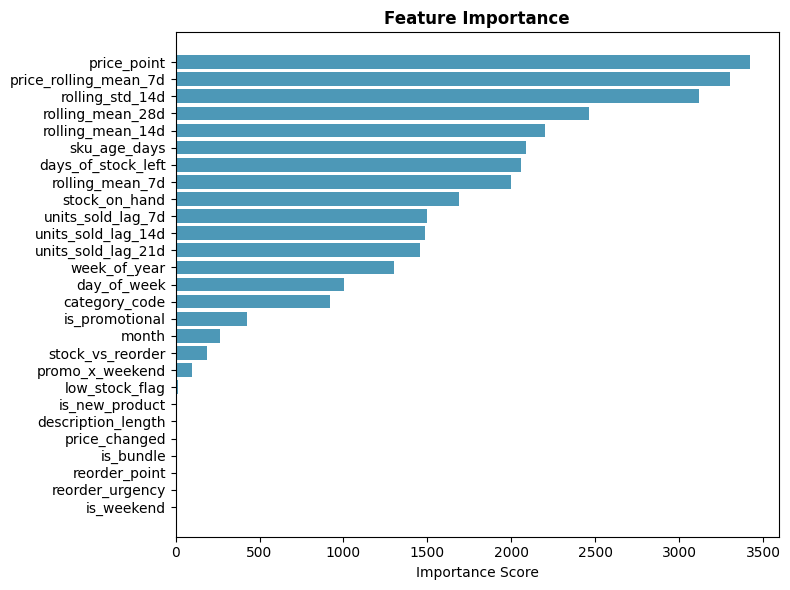

2026-05-01 08:06:40,816 — Saved → outputs/evaluation/feature_importance.png


In [5]:
# Feature importance — reusing evaluate.py function
plot_feature_importance(lgbm_model)

---
## 4. Prophet
> Runs one model per SKU. We sample top 10 SKUs by volume to keep it fast.

In [6]:
def run_prophet_on_sku(sku_id, train, test):
    """
    Train Prophet on one SKU and return predictions on test period.
    Prophet requires columns named ds (date) and y (target).
    """
    sku_train = train[train[SKU_COL] == sku_id][[DATE_COL, TARGET_COL]].copy()
    sku_test  = test[test[SKU_COL]  == sku_id][[DATE_COL, TARGET_COL]].copy()

    if len(sku_train) < 10 or len(sku_test) == 0:
        return None

    sku_train = sku_train.rename(columns={DATE_COL: 'ds', TARGET_COL: 'y'})

    model = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
    model.fit(sku_train)

    future = pd.DataFrame({'ds': sku_test[DATE_COL].values})
    preds  = model.predict(future)['yhat'].clip(lower=0).values

    mape = mean_absolute_percentage_error(sku_test[TARGET_COL].values, preds)
    return mape


# Run on top 10 SKUs by volume
top_skus       = train.groupby(SKU_COL)[TARGET_COL].sum().nlargest(10).index.tolist()
prophet_mapes  = []

for sku in top_skus:
    mape = run_prophet_on_sku(sku, train, test)
    if mape is not None:
        prophet_mapes.append(mape)
        print(f'  SKU {sku} — MAPE {mape:.2%}')

prophet_avg_mape = np.mean(prophet_mapes)
print(f'\nProphet average MAPE across top SKUs : {prophet_avg_mape:.2%}')

prophet_metrics = {
    'label': 'Prophet',
    'mape' : prophet_avg_mape,
    'rmse' : None,   # not computed — Prophet runs per SKU
    'bias' : None,
    'wape' : None,
}

2026-05-01 08:06:40,978 — Chain [1] start processing
2026-05-01 08:06:41,040 — Chain [1] done processing
2026-05-01 08:06:41,174 — Chain [1] start processing
2026-05-01 08:06:41,217 — Chain [1] done processing


  SKU sku_015 — MAPE 20.88%
  SKU sku_037 — MAPE 21.87%


2026-05-01 08:06:41,355 — Chain [1] start processing
2026-05-01 08:06:41,410 — Chain [1] done processing
2026-05-01 08:06:41,543 — Chain [1] start processing
2026-05-01 08:06:41,621 — Chain [1] done processing


  SKU sku_048 — MAPE 18.87%
  SKU sku_049 — MAPE 21.29%


2026-05-01 08:06:41,748 — Chain [1] start processing
2026-05-01 08:06:41,806 — Chain [1] done processing
2026-05-01 08:06:41,931 — Chain [1] start processing
2026-05-01 08:06:41,986 — Chain [1] done processing


...

  SKU sku_044 — MAPE 17.14%


2026-05-01 08:06:42,520 — Chain [1] start processing
2026-05-01 08:06:42,574 — Chain [1] done processing


  SKU sku_019 — MAPE 21.00%
  SKU sku_006 — MAPE 20.12%


2026-05-01 08:06:42,710 — Chain [1] start processing
2026-05-01 08:06:42,785 — Chain [1] done processing


  SKU sku_038 — MAPE 19.21%

Prophet average MAPE across top SKUs : 19.88%


---
## 5. Metrics Comparison

In [7]:
# ── Comparison table ───────────────────────────────────────────
comparison = pd.DataFrame([
    baseline_metrics,
    lgbm_metrics,
    prophet_metrics,
])

comparison['beats_baseline'] = comparison['mape'] < baseline_metrics['mape']
comparison['mape_%']         = (comparison['mape'] * 100).round(2).astype(str) + '%'

display(comparison[['label', 'mape_%', 'rmse', 'bias', 'wape', 'beats_baseline']])

,label,mape_%,rmse,bias,wape,beats_baseline
0,Naive Baseline,39.45%,7.635386,-5.012671,0.443844,False
1,LightGBM,17.41%,2.601191,-1.021650,0.151121,True
2,Prophet,19.88%,NaN,NaN,NaN,True


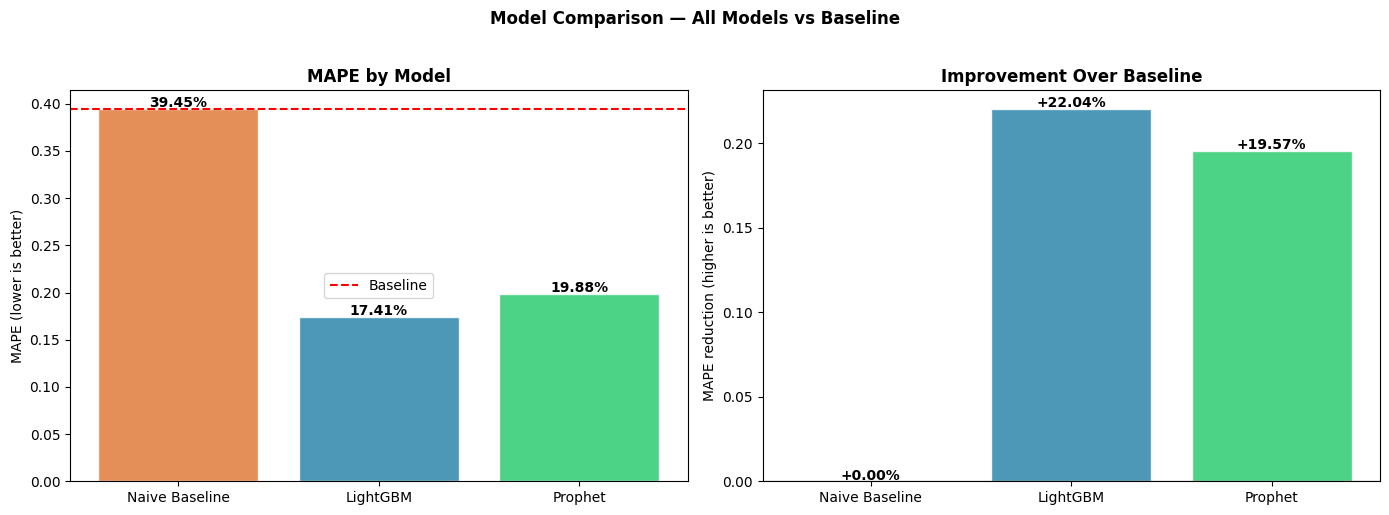

💾 Saved → outputs/evaluation/model_comparison.png


In [8]:
import os

# ── Visual comparison ──────────────────────────────────────────
labels = [baseline_metrics['label'], lgbm_metrics['label'], prophet_metrics['label']]
mapes  = [baseline_metrics['mape'],  lgbm_metrics['mape'],  prophet_metrics['mape']]
colors = ['#E07B39', '#2E86AB', '#2ECC71']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAPE bar chart
bars = axes[0].bar(labels, mapes, color=colors, alpha=0.85, edgecolor='white')
axes[0].axhline(baseline_metrics['mape'], color='red', linestyle='--', linewidth=1.5, label='Baseline')
axes[0].set_title('MAPE by Model', fontweight='bold')
axes[0].set_ylabel('MAPE (lower is better)')
axes[0].legend()
for bar, val in zip(bars, mapes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.2%}', ha='center', fontsize=10, fontweight='bold')

# Improvement over baseline
improvements = [0, baseline_metrics['mape'] - lgbm_metrics['mape'],
                baseline_metrics['mape'] - prophet_metrics['mape']]
bars2 = axes[1].bar(labels, improvements, color=colors, alpha=0.85, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Improvement Over Baseline', fontweight='bold')
axes[1].set_ylabel('MAPE reduction (higher is better)')
for bar, val in zip(bars2, improvements):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:+.2%}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Model Comparison — All Models vs Baseline', fontweight='bold', y=1.02)
plt.tight_layout()

# Create output directory if it doesn't exist
os.makedirs('../outputs/evaluation', exist_ok=True)
plt.savefig('../outputs/evaluation/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved → outputs/evaluation/model_comparison.png')

---
## 6. Walk-Forward Validation
> Simulates real production performance over time — reusing evaluate.py

2026-05-01 08:06:43,170 — Running walk-forward validation — 4 splits...
2026-05-01 08:06:43,810 —   Split 1 — cutoff 2024-06-05 — MAPE 1682777826050153.00%
2026-05-01 08:06:44,877 —   Split 2 — cutoff 2024-10-26 — MAPE 39.00%
2026-05-01 08:06:46,075 —   Split 3 — cutoff 2025-03-18 — MAPE 25.82%
2026-05-01 08:06:47,444 —   Split 4 — cutoff 2025-08-08 — MAPE 17.70%


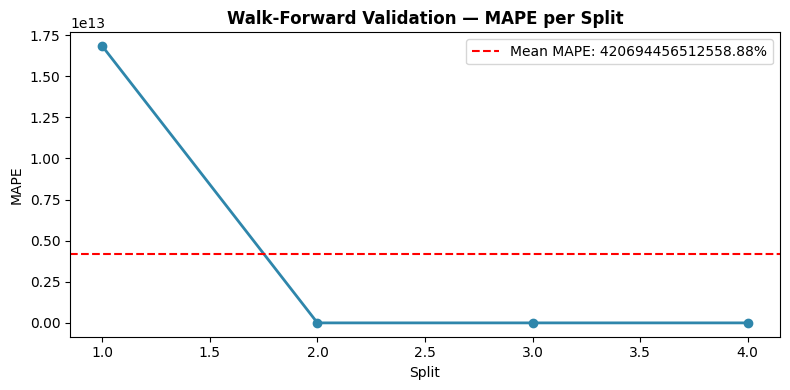

2026-05-01 08:06:47,834 — Saved → outputs/evaluation/walk_forward_mape.png


,split,cutoff,mape
0,1,2024-06-05,1.682778e+13
1,2,2024-10-26,3.899994e-01
2,3,2025-03-18,2.581615e-01
3,4,2025-08-08,1.770463e-01


In [9]:
# LightGBM walk-forward — reusing function from evaluate.py
wf_results = walk_forward_eval(lgbm_model, features_df, n_splits=4)
display(wf_results)

---
## 7. Verdict

In [10]:
best_model  = comparison.loc[comparison['mape'].idxmin(), 'label']
best_mape   = comparison['mape'].min()
improvement = baseline_metrics['mape'] - best_mape

print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  Best model        : {best_model}')
print(f'  MAPE              : {best_mape:.2%}')
print(f'  Beats baseline by : {improvement:.2%}')
print(f'  Production ready  : {"✅ Yes" if improvement > 0 else "❌ No — review features"}')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Best model        : LightGBM
  MAPE              : 17.41%
  Beats baseline by : 22.04%
  Production ready  : ✅ Yes
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


---
## 📝 Findings

| Model | MAPE | Beats Baseline | Notes |
|---|---|---|---|
| Naive Baseline | — | — | Minimum bar |
| LightGBM | — | — | |
| Prophet | — | — | Sampled top 10 SKUs only |

**Production decision →** *(fill in after running)*

**Next step →** `run_pipeline.py --mode train`